In [1]:
from langgraph.graph import START, StateGraph, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()
model = ChatOpenAI()

In [2]:
class PmtChain(TypedDict):
    title: str
    outline: str
    content: str
    evaluate: int

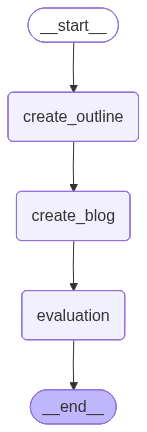

In [3]:
def create_outline(state: PmtChain)->PmtChain:
    title = state['title']
    pmt = f'generate an outline for a blog on topic {title}'
    outline = model.invoke(pmt).content
    state['outline'] = outline
    return state

def create_blog(state: PmtChain)-> PmtChain:
    title = state['title']
    outline = state['outline']
    pmt = f'write a detail blog on title {title} using following outline {outline}'
    blog = model.invoke(pmt).content
    state['content'] = blog
    return state

def evaluation(state: PmtChain) -> PmtChain:
    title = state['title']
    outline = state['outline']
    content = state['content']
    pmt = f"based on the outline {outline} rate my blog {content}. provide the score out of 100"
    eval = model.invoke(pmt).content
    state['evaluate'] = eval
    return state


graph = StateGraph(PmtChain)
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluation',evaluation)
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluation')
graph.add_edge('evaluation',END)
wfs = graph.compile()
wfs

In [4]:
init = {'title':'Raise of AI in World'}
final = wfs.invoke(init)
final

{'title': 'Raise of AI in World',
 'outline': "I. Introduction \n    A. Definition of artificial intelligence (AI)\n    B. Brief history of AI\n    C. Importance of AI in today's world\nII. Applications of AI in various industries\n    A. Healthcare \n        1. Use of AI in diagnosing and treating diseases\n        2. AI-powered medical devices\n    B. Finance \n        1. AI algorithms in stock trading \n        2. Fraud detection\n    C. Transportation \n        1. Self-driving cars\n        2. Traffic prediction and management\n    D. Retail \n        1. Personalized shopping recommendations\n        2. Inventory management \nIII. Ethical and societal implications of AI\n    A. Job displacement\n    B. Privacy concerns \n    C. Bias in AI algorithms\nIV. Future of AI \n    A. Advancements in AI technology \n    B. Potential impact of AI on society\n    C. Ethical considerations for the future development of AI \nV. Conclusion \n    A. Recap of the importance and impact of AI\n    B

In [5]:
print(final['outline'])

I. Introduction 
    A. Definition of artificial intelligence (AI)
    B. Brief history of AI
    C. Importance of AI in today's world
II. Applications of AI in various industries
    A. Healthcare 
        1. Use of AI in diagnosing and treating diseases
        2. AI-powered medical devices
    B. Finance 
        1. AI algorithms in stock trading 
        2. Fraud detection
    C. Transportation 
        1. Self-driving cars
        2. Traffic prediction and management
    D. Retail 
        1. Personalized shopping recommendations
        2. Inventory management 
III. Ethical and societal implications of AI
    A. Job displacement
    B. Privacy concerns 
    C. Bias in AI algorithms
IV. Future of AI 
    A. Advancements in AI technology 
    B. Potential impact of AI on society
    C. Ethical considerations for the future development of AI 
V. Conclusion 
    A. Recap of the importance and impact of AI
    B. Call to action for responsible development and use of AI in the future.


In [6]:
print(final['content'])

Artificial Intelligence (AI) has become a ubiquitous part of modern society, revolutionizing various industries and changing the way we live and work. From healthcare to finance, transportation to retail, AI is reshaping the world as we know it. In this blog, we will discuss the rise of AI in the world, exploring its applications in different sectors, and examining the ethical and societal implications of its widespread adoption.

Introduction

Artificial Intelligence, often referred to as AI, is the simulation of human intelligence processes by machines, especially computer systems. These processes include learning, reasoning, and self-correction. AI has a long and storied history, dating back to the mid-20th century when researchers began to explore the concept of intelligent machines. Over the years, AI has evolved significantly, with breakthroughs in machine learning, neural networks, and deep learning algorithms driving its advancement.

Today, AI plays a crucial role in various i

In [8]:
print(final['evaluate'])

I would rate this blog about Artificial Intelligence (AI) a 90 out of 100. It covers a wide range of topics related to AI, including its definition, history, applications in various industries, ethical and societal implications, and the future of AI. The content is well-structured, informative, and engaging, providing a comprehensive overview of the subject. Additionally, the concluding call to action for responsible development and use of AI adds a strong closing note to the blog. Great job!
